In [50]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
import seaborn as sns
import plotly.express as px

In [51]:
df_final = pd.read_csv('../data/df_final.csv')


In [52]:
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer

df_final['release_year'] = pd.to_datetime(df_final['release_date'], errors='coerce').dt.year.fillna(0)
X_num = df_final[['budget', 'revenue', 'mean_rating', 'num_votes', 'runtime', 
                   'vote_average_tmdb', 'vote_count_tmdb', 'std_rating', 'release_year']].fillna(0).values
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)
tfidf = TfidfVectorizer(max_features=100, stop_words='english') 
X_text = tfidf.fit_transform(df_final['all_tags'].fillna(''))
mlb = MultiLabelBinarizer()
X_genres = mlb.fit_transform(df_final['genres'].str.split('|'))
X_combined = hstack([X_num_scaled, X_text])
#X_combined = hstack([X_num_scaled, X_text, X_genres])

<p style = 'color: blue; font-weight: bold'>
T-SNE
<p>


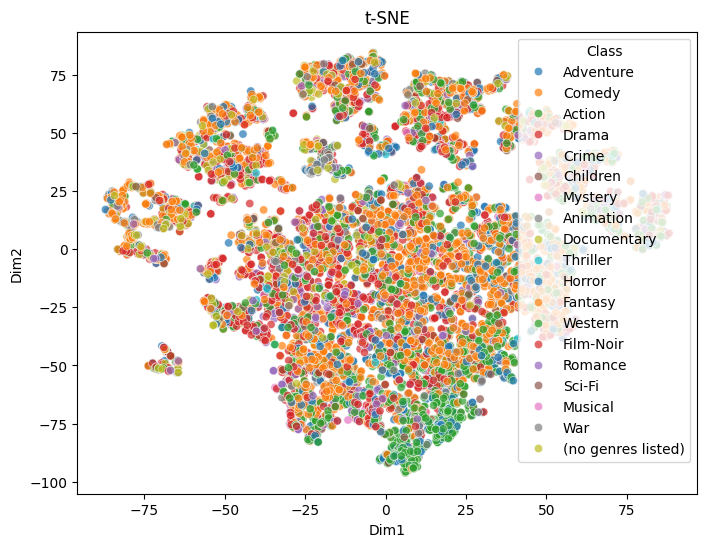

In [53]:
tsne = TSNE(n_components=2, perplexity=30, init='random', learning_rate='auto')
X_embedded = tsne.fit_transform(X_combined.toarray())
df_tsne = pd.DataFrame(X_embedded, columns=['Dim1', 'Dim2'])
df_tsne['Class'] = df_final['genres'].str.split('|').str[0].values

df_tsne.to_csv('../data/df_tsne.csv', index=False)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_tsne,x='Dim1', y='Dim2', hue='Class', palette='tab10',alpha=0.7)
plt.title('t-SNE')
plt.savefig('tsne.png')
plt.show()

In [54]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_embedded, df_tsne['Class'])
print(f"Silhouette Score : {score:.3f}")

Silhouette Score : -0.214


<p style = 'color:blue; font-weight: bold'>
Kmeans
<p>

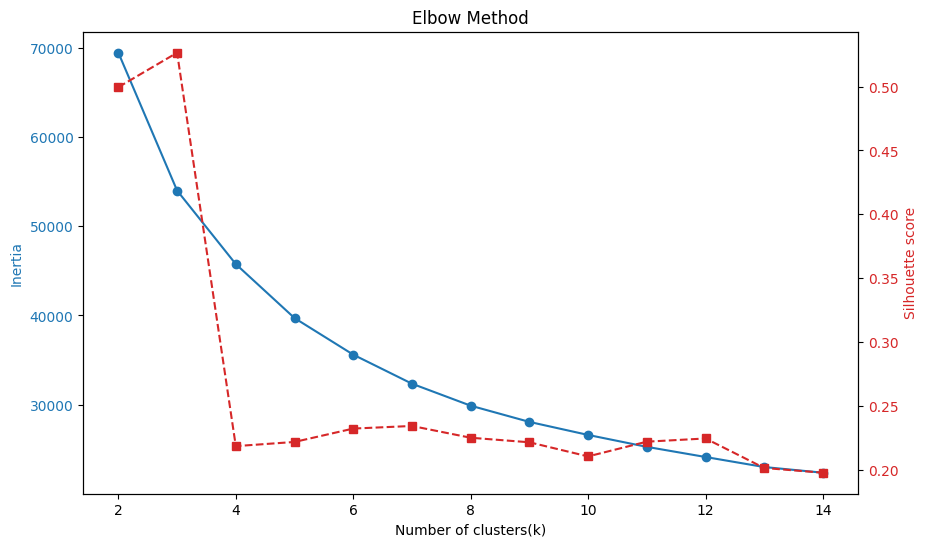

In [55]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
K_range = range(2, 15)  

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_combined)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_combined, labels))

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Number of clusters(k)')
ax1.set_ylabel('Inertia', color='tab:blue')
ax1.plot(K_range, inertias, 'o-', color='tab:blue', label='Inertie')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.set_ylabel( 'Silhouette score', color='tab:red')
ax2.plot(K_range, silhouettes, 's--', color='tab:red', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Elbow Method')
plt.show()

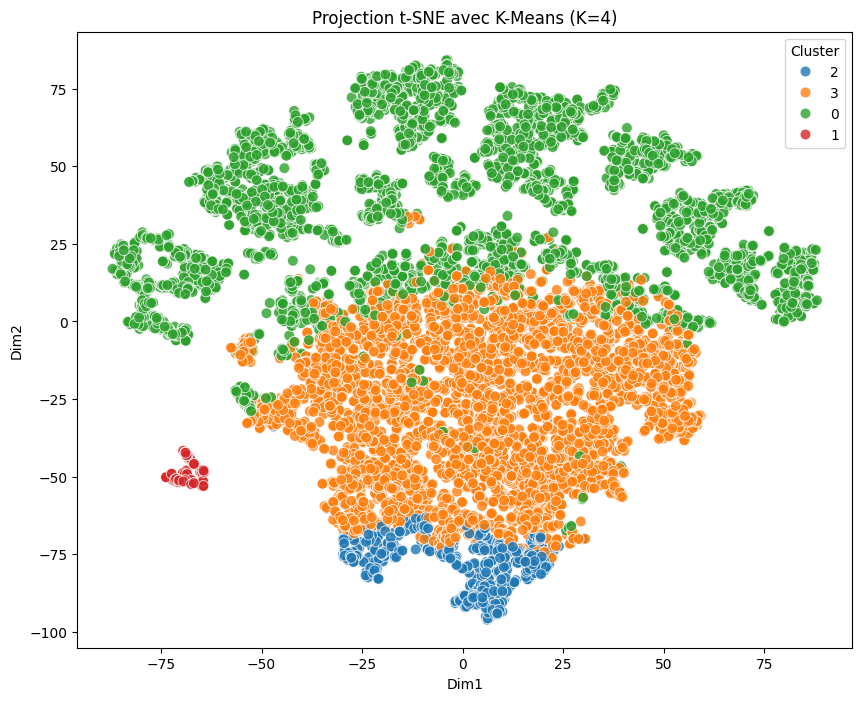

In [56]:
best_k = 4
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_labels = km_final.fit_predict(X_combined)

df_tsne['Cluster'] = final_labels.astype(str)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_tsne, 
    x='Dim1', 
    y='Dim2', 
    hue='Cluster', 
    palette='tab10',
    s=60,
    alpha=0.8
)
plt.title(f'Projection t-SNE avec K-Means (K={best_k})')
plt.show()

In [57]:
fig = px.scatter(df_tsne, x = 'Dim1', y= 'Dim2', color= 'Class')
fig.update_layout(
    title="T-SNE visualization",
    xaxis_title="First Component",
    yaxis_title="Second Component",
)
fig.write_image('tsne.png')
fig.show()

PCA

In [58]:
pca = PCA(n_components = 2)
scaler = StandardScaler()
y = df_tsne['Class']
X_pca = pca.fit_transform(X_combined)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca.to_csv('../data/df_pca.csv')


fig_pca = px.scatter(x = X_pca[:,0], y =X_pca[:,1], color = y)
fig_pca.update_layout(
    title="PCA visualization",
    xaxis_title="Dimension 1",
    yaxis_title="Dimension 2",
)
fig_pca.write_image('pca.png')
fig_pca.show()
pca_var = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(pca_var)
print(f"Variance totale expliquée : {cumulative_variance[-1] * 100:.2f}%")

Variance totale expliquée : 55.46%


In [59]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_pca, df_tsne['Class'])
print(f"Silhouette Score : {score:.3f}")

Silhouette Score : -0.379


In [60]:
pca_test = PCA(n_components=10) 
pca_test.fit(X_combined)
variance_ratio = pca_test.explained_variance_ratio_
cumulative_variance2 = np.cumsum(variance_ratio)

print(f"Variance totale expliquée : {cumulative_variance2[-1] * 100:.2f}%")

Variance totale expliquée : 99.20%


In [61]:
for i, v in enumerate(np.cumsum(pca_test.explained_variance_ratio_)):
    print(f"PC{i+1} : {v*100:.2f}%")

PC1 : 35.39%
PC2 : 55.46%
PC3 : 68.35%
PC4 : 78.05%
PC5 : 85.35%
PC6 : 92.02%
PC7 : 95.01%
PC8 : 97.26%
PC9 : 99.06%
PC10 : 99.20%


ISOMAP

In [62]:
embedding = Isomap(n_components = 2, n_neighbors= 30)
X_isomap = embedding.fit_transform(X_combined)
fig_iso = px.scatter( x = X_isomap[:,0], y =X_isomap[:,1], color = y, opacity = 0.7, title = 'Isomap Projection')
fig_iso.show()

c:\Users\kalai\anaconda3\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning:

The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.

c:\Users\kalai\anaconda3\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



LocallyLinearEmbedding (LLE)

In [63]:
embedding = LocallyLinearEmbedding(n_components = 2)
X_transformed = embedding.fit_transform(X_num_scaled)
fig_lle = px.scatter( x = X_transformed[:,0], y =X_transformed[:,1], color = y, opacity = 0.7, title = 'LLE Projection')
fig_lle.show()

Self Organizing Map

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 1.2539563897380122


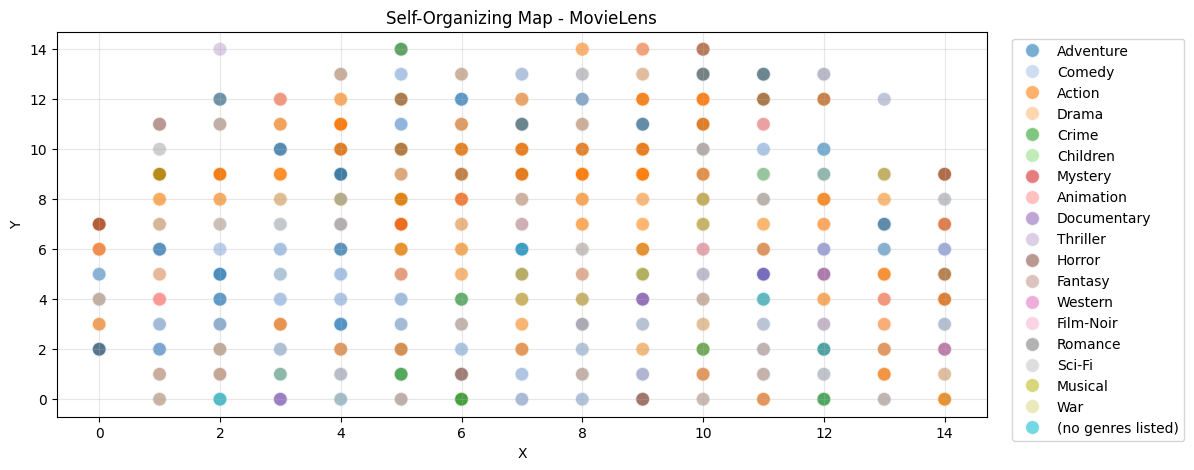

In [64]:
from minisom import MiniSom

X_dense = X_combined.toarray()
som = MiniSom(x =15,y = 15, input_len = X_dense.shape[1],sigma = 1.5, learning_rate = 0.5, random_seed = 42)
som.train_random(X_dense, num_iteration = 1000, verbose = True)
som_coords = np.array([som.winner(x) for x in X_dense])

df_som = pd.DataFrame(som_coords, columns=['X', 'Y'])
df_som['Class'] = df_final['genres'].str.split('|').str[0].values

plt.figure(figsize=(12, 5))
sns.scatterplot(data=df_som, x='X', y='Y', hue='Class', palette='tab20', s=100, alpha=0.6)
plt.title('Self-Organizing Map - MovieLens')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

Les points sont superposés les uns sur les autres donc on rajoute du bruit sur les coordonnées pour visualiser correctement.

 [ 5000 / 5000 ] 100% - 0:00:00 left 
 quantization error: 0.96456727632124


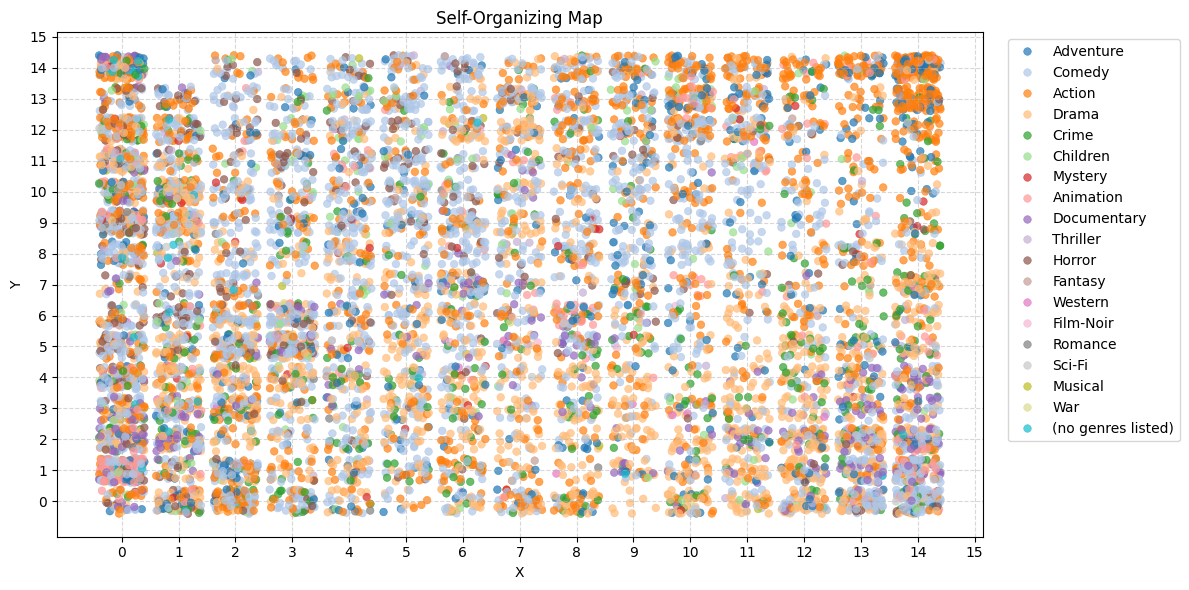

In [65]:
X_dense = X_combined.toarray()

som = MiniSom(x=15, y=15, input_len=X_dense.shape[1], sigma=1.5, learning_rate=0.5, random_seed=42)
som.train_random(X_dense, num_iteration=5000, verbose=True)

winners = np.array([som.winner(x) for x in X_dense])

jitter_x = np.random.rand(len(winners)) - 0.5
jitter_y = np.random.rand(len(winners)) - 0.5

df_som = pd.DataFrame()
df_som['X'] = winners[:, 0] + jitter_x * 0.8
df_som['Y'] = winners[:, 1] + jitter_y * 0.8
df_som['Class'] = df_final['genres'].str.split('|').str[0].values

plt.figure(figsize=(12, 6))
plt.xticks(np.arange(16))
plt.yticks(np.arange(16))
plt.grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(data=df_som,x='X',y='Y',hue='Class',palette='tab20',s=30,alpha=0.7,edgecolor=None)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('Self-Organizing Map')
plt.tight_layout()
plt.show()

In [66]:
# Ca sert à quoi ça ???? 
df_final_genre = df_final.copy()
df_final_genre['genres'] = df_final['genres'].str.split('|').str[0].values
df_final_genre.to_csv('../data/df_final_genre.csv', index = False)

In [67]:
df_mining_supergenre = pd.read_csv('../data/supergenres.csv')

cluster_names = {
    1: "Divertissement",    # Action, Adventure, Animation, Children, Comedy, Fantasy, Sci-Fi
    2: "Suspense/Horreur",  # Crime, Horror, Mystery, Thriller
    3: "Autres",            # Documentary, Drama, Film-Noir, IMAX, Musical, Romance, War, Western
}
df_mining_supergenre['super_genre_label'] = df_mining_supergenre['super_genre'].map(cluster_names).fillna("Autres")

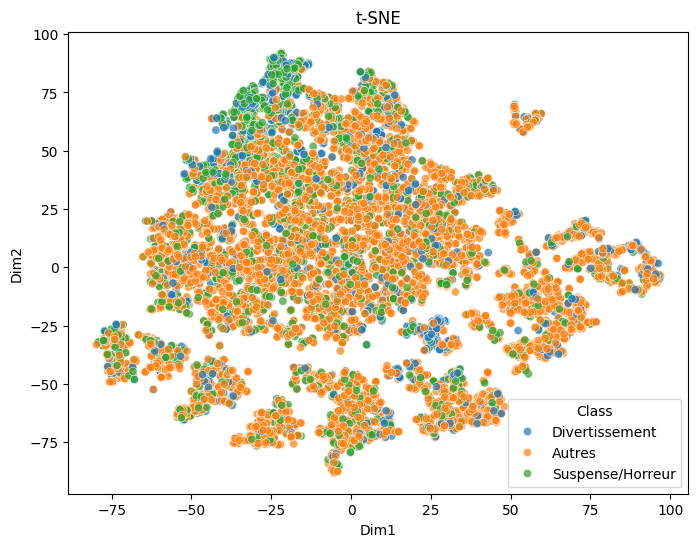

In [68]:

tsne = TSNE(n_components=2, perplexity=30, init='random', learning_rate='auto')
X_embedded = tsne.fit_transform(X_combined.toarray())
df_tsne = pd.DataFrame(X_embedded, columns=['Dim1', 'Dim2'])
df_tsne['Class'] = df_mining_supergenre['super_genre_label']
df_tsne.to_csv('../data/df_tsne.csv', index = False)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_tsne,x='Dim1', y='Dim2', hue='Class', palette='tab10',alpha=0.7)
plt.title('t-SNE')
plt.savefig('tsne_supergenres')
plt.show()


In [69]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_pca, df_tsne['Class'])
print(f"Silhouette Score : {score:.3f}")

Silhouette Score : 0.120


In [71]:
import networkx as nx
import plotly.graph_objects as go

df = pd.read_csv('../data/df_final.csv')
df_sample = df.nlargest(100, 'num_votes').reset_index(drop=True)

G = nx.Graph()

for _, row in df_sample.iterrows():
    film_node = f"film_{row['movieId']}"
    G.add_node(film_node, 
               type='film', 
               title=row['title'],
               rating=round(row['mean_rating'], 2),
               genres=row['genres'])
    
    genres = str(row['genres']).split('|')
    for genre in genres:
        if genre not in G.nodes:
            G.add_node(genre, type='genre', title=genre)
        G.add_edge(film_node, genre)


film_nodes  = [n for n, d in G.nodes(data=True) if d['type'] == 'film']
genre_nodes = [n for n, d in G.nodes(data=True) if d['type'] == 'genre']

pos = nx.spring_layout(G, seed=42, k=0.8)

edge_x, edge_y = [], []
for u, v in G.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    mode='lines',
    line=dict(width=0.5, color='rgba(180,180,180,0.3)'),
    hoverinfo='none',
    showlegend=False
)

film_x, film_y, film_hover, film_sizes = [], [], [], []

for node in film_nodes:
    x, y = pos[node]
    film_x.append(x)
    film_y.append(y)
    film_sizes.append(6 + G.degree(node) * 1.5) 
    film_hover.append(
        f"<b>{G.nodes[node]['title']}</b><br>"
        f"Genres : {G.nodes[node]['genres'].replace('|', ' | ')}<br>"
        f"Rating : {G.nodes[node]['rating']}"
    )

film_trace = go.Scatter(
    x=film_x, y=film_y,
    mode='markers',
    name='Films',
    hovertext=film_hover,
    hoverinfo='text',
    marker=dict(
        size=film_sizes,
        color='#4e9af1',
        opacity=0.7,
        line=dict(width=0.5, color='white')
    )
)

genre_colors = {
    'Action':'#e74c3c',     'Adventure':'#e67e22',  'Animation':'#f1c40f',
    'Children':'#2ecc71',   'Comedy':'#1abc9c',      'Crime':'#9b59b6',
    'Documentary':'#34495e','Drama':'#e91e63',        'Fantasy':'#00bcd4',
    'Film-Noir':'#607d8b',  'Horror':'#c0392b',       'Mystery':'#8e44ad',
    'Romance':'#ff69b4',    'Thriller':'#d35400',     'Western':'#795548'
}

genre_x, genre_y, genre_text, genre_hover, genre_color_list = [], [], [], [], []

for node in genre_nodes:
    x, y = pos[node]
    genre_x.append(x)
    genre_y.append(y)
    genre_text.append(node)
    genre_color_list.append(genre_colors.get(node, '#aaaaaa'))
    genre_hover.append(
        f"<b>Genre : {node}</b><br>"
        f"Nombre de films : {G.degree(node)}"
    )

genre_trace = go.Scatter(
    x=genre_x, y=genre_y,
    mode='markers+text',
    name='Genres',
    text=genre_text,
    textposition='top center',
    textfont=dict(size=11, color='white'),
    hovertext=genre_hover,
    hoverinfo='text',
    marker=dict(
        size=[20 + G.degree(n) * 1.5 for n in genre_nodes], 
        color=genre_color_list,
        opacity=0.95,
        line=dict(width=2, color='white')
    )
)

fig = go.Figure(
    data=[edge_trace, film_trace, genre_trace],
    layout=go.Layout(
        title=dict(text='Graphe Bipartite Films ↔ Genres', font=dict(size=18, color='white')),
        showlegend=True,
        hovermode='closest',
        plot_bgcolor='#0f0f1a',
        paper_bgcolor='#0f0f1a',
        font=dict(color='white'),
        height=800,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        legend=dict(
            bgcolor='rgba(255,255,255,0.1)',
            bordercolor='white',
            borderwidth=1
        )
    )
)

fig.show()

In [72]:
import networkx as nx
import plotly.graph_objects as go

df_movies = pd.read_csv('../data/movies.csv')
df_mining = df_movies[['movieId', 'title', 'genres']].copy()
df_mining['genres'] = df_mining['genres'].apply(lambda x: x.split('|'))

G_genres = nx.Graph()

for _, row in df_mining.iterrows():
    genres = row['genres']
    for i in range(len(genres)):
        for j in range(i+1, len(genres)):
            if G_genres.has_edge(genres[i], genres[j]):
                G_genres[genres[i]][genres[j]]['weight'] += 1
            else:
                G_genres.add_edge(genres[i], genres[j], weight=1)

from networkx.algorithms.community import greedy_modularity_communities
communities = greedy_modularity_communities(G_genres, weight='weight')

genre_community = {}
for i, community in enumerate(communities):
    for genre in community:
        genre_community[genre] = i

print("Communautés détectées :")
for i, community in enumerate(communities):
    print(f"  Communauté {i} : {sorted(community)}")

pos = nx.spring_layout(G_genres, seed=42, weight='weight')

edge_x, edge_y, edge_width = [], [], []
for u, v, data in G_genres.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    mode='lines',
    line=dict(width=0.8, color='rgba(200,200,200,0.3)'),
    hoverinfo='none',
    showlegend=False
)

community_colors = ['#e74c3c','#2ecc71','#3498db','#f39c12','#9b59b6','#1abc9c','#e91e63','#95a5a6']

node_x, node_y, node_text, node_color, node_size, node_hover = [], [], [], [], [], []

for node in G_genres.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(node)
    comm = genre_community.get(node, 0)
    node_color.append(community_colors[comm % len(community_colors)])
    node_size.append(15 + G_genres.degree(node, weight='weight') / 50)
    neighbors = sorted(G_genres[node].items(), key=lambda x: x[1]['weight'], reverse=True)[:3]
    top_neighbors = ', '.join([f"{n}({d['weight']})" for n, d in neighbors])
    node_hover.append(
        f"<b>{node}</b><br>"
        f"Communauté : {comm}<br>"
        f"Co-occurrences totales : {G_genres.degree(node, weight='weight')}<br>"
        f"Top voisins : {top_neighbors}"
    )

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    text=node_text,
    textposition='top center',
    textfont=dict(size=11, color='white'),
    hovertext=node_hover,
    hoverinfo='text',
    marker=dict(
        size=node_size,
        color=node_color,
        opacity=0.9,
        line=dict(width=2, color='white')
    ),
    showlegend=False
)

fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title=dict(text='Genre Co-occurrence Graph — Communities = Super-genres',
                   font=dict(size=16, color='white')),
        plot_bgcolor='#0f0f1a',
        paper_bgcolor='#0f0f1a',
        font=dict(color='white'),
        height=700,
        hovermode='closest',
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    )
)

fig.show()
fig.write_image('genre_cooccurrence_graph.png', width=1200, height=700)

Communautés détectées :
  Communauté 0 : ['Action', 'Crime', 'Film-Noir', 'Horror', 'Mystery', 'Sci-Fi', 'Thriller']
  Communauté 1 : ['Comedy', 'Documentary', 'Drama', 'Musical', 'Romance', 'War', 'Western']
  Communauté 2 : ['Adventure', 'Animation', 'Children', 'Fantasy', 'IMAX']


In [ ]:
from rdflib import Graph, URIRef, Literal, Namespace
from rdflib.namespace import RDF, RDFS, OWL

g = Graph()
EX = Namespace("http://movielens.org/")

# Chaque film est un nœud
for _, row in df_mining.iterrows():
    film = URIRef(EX + f"film/{row['movieId']}")
    g.add((film, RDF.type, EX.Film))
    g.add((film, EX.title, Literal(row['title'])))
    
    for genre in row['genres']:
        genre_node = URIRef(EX + f"genre/{genre.replace(' ', '_')}")
        g.add((genre_node, RDF.type, EX.Genre))
        g.add((film, EX.hasGenre, genre_node))

print(f"Graphe original : {len(g)} triples")

g_summary = Graph()

community_map = {
    'Action': 'Sombre_Suspense', 'Crime': 'Sombre_Suspense',
    'Horror': 'Sombre_Suspense', 'Mystery': 'Sombre_Suspense',
    'Thriller': 'Sombre_Suspense', 'Film-Noir': 'Sombre_Suspense',
    'Sci-Fi': 'Sombre_Suspense',
    'Adventure': 'Famille', 'Animation': 'Famille',
    'Children': 'Famille', 'Fantasy': 'Famille', 'IMAX': 'Famille',
    'Comedy': 'Drame_Autres', 'Documentary': 'Drame_Autres',
    'Drama': 'Drame_Autres', 'Musical': 'Drame_Autres',
    'Romance': 'Drame_Autres', 'War': 'Drame_Autres',
    'Western': 'Drame_Autres'
}

# Super-nœuds = classes d'équivalence
for community in set(community_map.values()):
    super_node = URIRef(EX + f"supergenre/{community}")
    g_summary.add((super_node, RDF.type, EX.SuperGenre))
    
    # Films dans cette communauté
    films_in_community = df_mining[
        df_mining['genres'].apply(
            lambda x: community_map.get(x[0]) == community
        )
    ]
    
    g_summary.add((super_node, EX.filmCount, 
                   Literal(len(films_in_community))))
    

    genres_in_community = [g for g, c in community_map.items() if c == community]
    for genre in genres_in_community:
        genre_node = URIRef(EX + f"genre/{genre.replace(' ', '_')}")
        g_summary.add((super_node, EX.containsGenre, genre_node))

for _, row in df_mining.iterrows():
    genres = row['genres']
    comms = list(set([community_map.get(g) for g in genres if g in community_map]))
    for i in range(len(comms)):
        for j in range(i+1, len(comms)):
            if comms[i] and comms[j]:
                s = URIRef(EX + f"supergenre/{comms[i]}")
                o = URIRef(EX + f"supergenre/{comms[j]}")
                g_summary.add((s, EX.coOccursWith, o))

print(f"Graphe résumé : {len(g_summary)} triples")
g_summary.serialize("quotient_graph.ttl", format="turtle")

Graphe original : 41588 triples
Graphe résumé : 29 triples


<Graph identifier=N9496efdcf942497cb3f09ad45266c89f (<class 'rdflib.graph.Graph'>)>

In [74]:
query = """
PREFIX ex: <http://movielens.org/>
SELECT ?supergenre ?filmCount WHERE {
    ?supergenre a ex:SuperGenre ;
                ex:filmCount ?filmCount .
}
ORDER BY DESC(?filmCount)
"""
for row in g_summary.query(query):
    print(f"{row.supergenre} : {row.filmCount} films")

http://movielens.org/supergenre/Drame_Autres : 5479 films
http://movielens.org/supergenre/Sombre_Suspense : 3039 films
http://movielens.org/supergenre/Famille : 1190 films
